---
---
---

# **프로젝트: Stable diffusion 실습**



**실험 목표**

*   Stable Diffusion의 Latent space에서 선형 보간(interpolation)이 생성 이미지의 스타일/구도/객체 특성을 어떻게 연속적으로 변화시키는지 분석
*   DreamBooth(LoRA) 미세조정을 통해 Instance를 모델에 주입하고, 토큰(식별자) + 클래스 프롬프트로 재현 가능함을 검증
*   Checkpoint와 LoRA를 조합하여 파이프라인 구성 능력(가중치 로드, 프롬프트 설계, 하이퍼파라미터 조정)을 습득





**실험 설정**

*   Prompt interpolation 설정(노트북 2~3번)

    *   사용 모델 및 파이프라인 : KerasCV StableDiffusion (512×512)
    *   임베딩 생성: encode_text(prompt) → text embedding
    *   보간 방식: linspace(embedding_a, embedding_b, steps)
    *   생성 조건: diffusion noise 고정(seed 고정)(임베딩 변화만의 영향을 보기 위함)

*   DreamBooth(LoRA) 미세조정 설정

    *   데이터 구성 : Instance 이미지 - 5~6장, Class 이미지 - 100장 이상
    *   학습 방식 : Diffusers DreamBooth LoRA 스크립트
        *   resolution : 512
        *   prior preservation 사용(prior_loss_weight=1.0)

*   LoRA 적용

    *   guidance_scale : 6.5~7.5
    *   steps : 15~25 (T4 환경)
    *   해상도 : 512


**0. 런타임 환경 체크**

In [ ]:
import os, sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35


**1. 패키지 설치**

In [ ]:
!pip -q install -U keras-cv tensorflow matplotlib pillow tqdm
!pip -q install -U diffusers transformers accelerate safetensors

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

**2. Prompt 4개 설정 + 파이프라인 준비 (KerasCV StableDiffusion)**

In [ ]:
import keras
import keras_cv
from keras import ops

try:
    keras.mixed_precision.set_global_policy("mixed_float16")
    print("mixed precision enabled")
except Exception as e:
    print("mixed precision not set:", e)

# Stable Diffusion (KerasCV) 로드
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512, jit_compile=True)

mixed precision enabled
By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


In [ ]:
# 4개 프롬프트
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

prompts = [prompt_1, prompt_2, prompt_3, prompt_4]
prompts

['A watercolor painting of a Golden Retriever at the beach',
 'A still life DSLR photo of a bowl of fruit',
 'The eiffel tower in the style of starry night',
 'An architectural sketch of a skyscraper']

**2-1. 임베딩(텍스트 인코딩) 생성**

In [ ]:
encodings = [ops.squeeze(model.encode_text(p)) for p in prompts]
for i, e in enumerate(encodings, 1):
    print(f"encoding_{i} shape:", e.shape)

encoding_1 shape: (77, 768)
encoding_2 shape: (77, 768)
encoding_3 shape: (77, 768)
encoding_4 shape: (77, 768)


**2-2. 두 프롬프트 사이 선형 보간 + 시각화 (2개 프롬프트 기준)**

35/35 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step


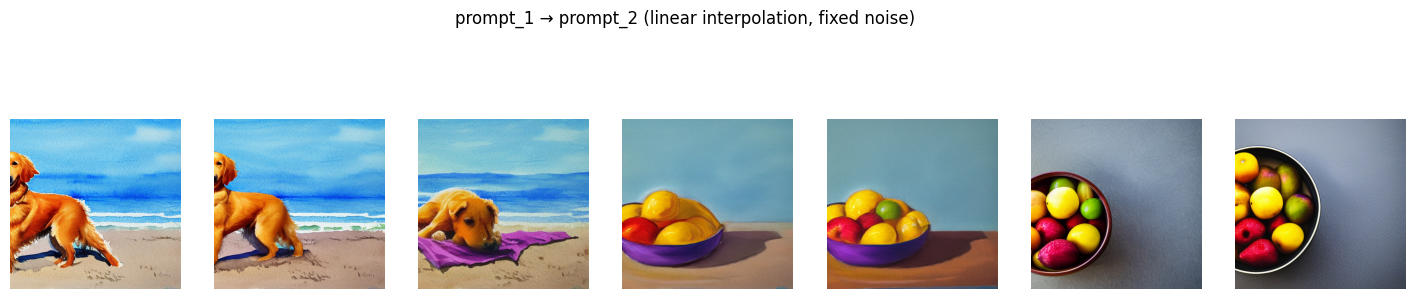

'prompt1_to_prompt2.gif'

In [ ]:
def export_as_gif(filename, images, frames_per_second=6, rubber_band=True):
    # images: list[PIL.Image]
    if rubber_band and len(images) > 2:
        images = images + images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )
    return filename

def show_row(images, title=None, figsize=(18, 4)):
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(1, len(images), i+1)
        ax.imshow(img)
        ax.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

interpolation_steps = 7  # 중간지점 관찰용(30~150까지 가능)

encoding_1 = encodings[0]
encoding_2 = encodings[1]

interpolated_encodings = ops.linspace(encoding_1, encoding_2, interpolation_steps)

# diffusion noise 고정(텍스트 임베딩 변화만 봄)
seed = 12345
noise = keras.random.normal((512 // 8, 512 // 8, 4), seed=seed)

images_np = model.generate_image(
    interpolated_encodings,
    batch_size=interpolation_steps,
    diffusion_noise=noise,
    num_steps=35,   # 속도/품질 절충(25~50 사이값)
)

images = [Image.fromarray(img) for img in images_np]
show_row(images, title="prompt_1 → prompt_2 (linear interpolation, fixed noise)")
gif_path = export_as_gif("prompt1_to_prompt2.gif", images, frames_per_second=4, rubber_band=True)
gif_path

**2-3. 4개 프롬프트로 2D 그리드(4-way interpolation) 만들기**

- 좌상단: prompt_1  
- 우상단: prompt_2  
- 좌하단: prompt_3  
- 우하단: prompt_4

30/30 ━━━━━━━━━━━━━━━━━━━━ 88s 730ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 691ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 689ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 673ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 658ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 663ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 693ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 21s 691ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 679ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 671ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 665ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 669ms/step


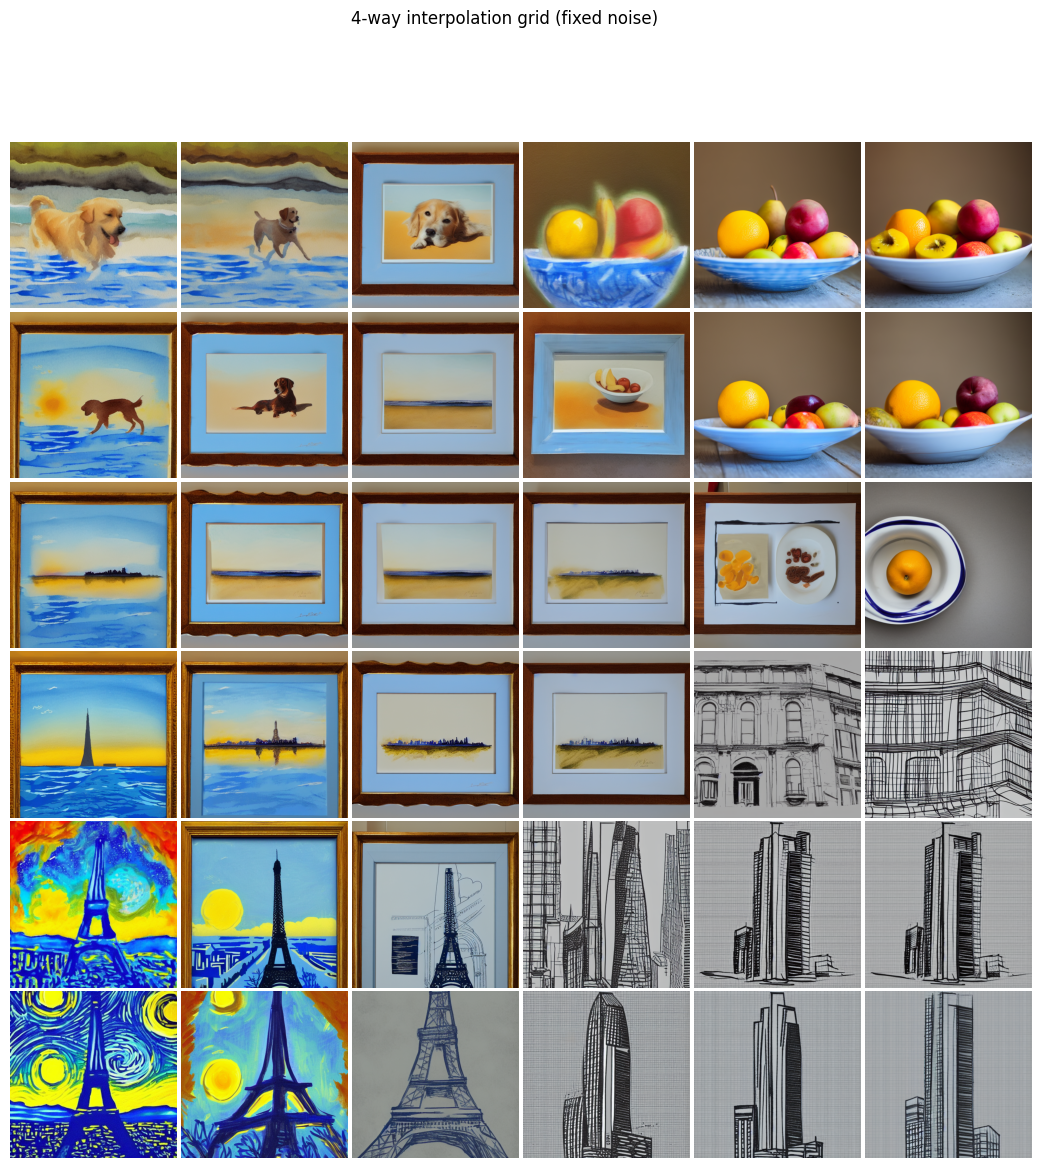

In [ ]:
def plot_grid(images_np, grid_size, scale=2.2, title=None):
    fig, axs = plt.subplots(grid_size, grid_size, figsize=(grid_size*scale, grid_size*scale))
    plt.subplots_adjust(wspace=0.02, hspace=0.02)
    if title:
        fig.suptitle(title)
    for ax in axs.flat:
        ax.axis("off")
    images_np = images_np.astype("uint8")
    for i in range(min(grid_size * grid_size, len(images_np))):
        axs.flat[i].imshow(images_np[i])
    plt.show()

grid_n = 6
batch_size = 3
batches = (grid_n * grid_n) // batch_size

e1, e2, e3, e4 = encodings
noise = keras.random.normal((512 // 8, 512 // 8, 4), seed=42)

# 2중 linspace로 2D 보간 그리드 만들기
interpolated = ops.linspace(
    ops.linspace(e1, e2, grid_n),
    ops.linspace(e3, e4, grid_n),
    grid_n,
)
interpolated = ops.reshape(interpolated, (grid_n * grid_n, 77, 768))

batched = ops.split(interpolated, batches)
imgs = []
for b in range(batches):
    imgs.append(
        model.generate_image(
            batched[b],
            batch_size=batch_size,
            diffusion_noise=noise,
            num_steps=30,
        )
    )
imgs = np.concatenate(imgs, axis=0)

plot_grid(imgs, grid_size=grid_n, title="4-way interpolation grid (fixed noise)")

**3. 관찰 및 분석 기록 템플릿**

In [ ]:
analysis_notes = {
    "prompt_pair": "prompt_1 ↔ prompt_2",
    "fixed_noise_observations": [
        "예: 수채화 질감이 중간 지점에서 점진적으로 사라지고, DSLR 광원/피사계심도가 강화됨",
        "예: 객체 변환(개→정물) 과정에서 배경(해변) 요소가 과일 그릇 배경으로 재해석됨",
    ],
    "varying_noise_observations": [
        "예: 동일 보간 단계에서도 이미지 다양성이 커져 전이가 덜 단조로움",
    ],
    "manifold_intuition": [
        "예: 임베딩 공간에서 선형 보간이 항상 '의미적으로 자연스러운' 경로는 아니며, 중간에 혼합/왜곡이 발생",
    ],
}
analysis_notes

{'prompt_pair': 'prompt_1 ↔ prompt_2',
 'fixed_noise_observations': ['예: 수채화 질감이 중간 지점에서 점진적으로 사라지고, DSLR 광원/피사계심도가 강화됨',
  '예: 객체 변환(개→정물) 과정에서 배경(해변) 요소가 과일 그릇 배경으로 재해석됨'],
 'varying_noise_observations': ['예: 동일 보간 단계에서도 이미지 다양성이 커져 전이가 덜 단조로움'],
 'manifold_intuition': ["예: 임베딩 공간에서 선형 보간이 항상 '의미적으로 자연스러운' 경로는 아니며, 중간에 혼합/왜곡이 발생"]}

**4. Random/Circular walk + (Un)conditional Guidance Scale**

In [ ]:
# 선택 실행 부분 :  SD3(KerasHub) 설치/로드가 필요한 경우
# !pip -q install -U git+https://github.com/keras-team/keras-hub.git

**5. DreamBooth 미세조정 (Instance 5–6장 + Class 100장 이상)**

In [ ]:
DATA_ROOT = "/content/dreambooth_data"
INSTANCE_DIR = os.path.join(DATA_ROOT, "instance")
CLASS_DIR = os.path.join(DATA_ROOT, "class")

unique_id = "sks"
class_label = "dog"
instance_prompt = f"a photo of {unique_id} {class_label}"
class_prompt = f"a photo of {class_label}"

print("INSTANCE_DIR:", INSTANCE_DIR)
print("CLASS_DIR:", CLASS_DIR)
print("instance_prompt:", instance_prompt)
print("class_prompt:", class_prompt)

INSTANCE_DIR: /content/dreambooth_data/instance
CLASS_DIR: /content/dreambooth_data/class
instance_prompt: a photo of sks dog
class_prompt: a photo of dog


**5-1. class 이미지를 모델로 생성하기**

In [ ]:
# class 이미지 자동 생성
import hashlib
from tqdm import tqdm

os.makedirs(CLASS_DIR, exist_ok=True)

num_imgs_to_generate = 120  # 100장 이상 권장
batch_size = 3

generated = 0
for _ in tqdm(range((num_imgs_to_generate + batch_size - 1)//batch_size)):
    imgs = model.text_to_image(class_prompt, batch_size=batch_size)
    for img in imgs:
        pil = Image.fromarray(img)
        h = hashlib.sha1(pil.tobytes()).hexdigest()
        fn = os.path.join(CLASS_DIR, f"{h}.jpg")
        if not os.path.exists(fn):
            pil.save(fn)
            generated += 1
        if generated >= num_imgs_to_generate:
            break
    if generated >= num_imgs_to_generate:
        break

print("generated class images:", generated)

  0%|          | 0/40 [00:00<?, ?it/s]

50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 677ms/step


  2%|▎         | 1/40 [00:34<22:26, 34.53s/it]

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 669ms/step


  5%|▌         | 2/40 [01:08<21:42, 34.27s/it]

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 672ms/step


 98%|█████████▊| 39/40 [22:11<00:34, 34.13s/it]

50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 666ms/step


 98%|█████████▊| 39/40 [22:45<00:35, 35.01s/it]

generated class images: 120


**5-2. DreamBooth 학습 (Diffusers + LoRA DreamBooth 추천)**

In [ ]:
# HuggingFace 토큰이 필요한 모델을 쓸 경우(예: stabilityai 계열), 여기서 로그인 필요할 수 있습니다.
# from huggingface_hub import notebook_login
# notebook_login()

In [ ]:
# 학습 설정
MODEL_NAME = "runwayml/stable-diffusion-v1-5"   # 또는 stabilityai/stable-diffusion-2-1 등
OUTPUT_DIR = "/content/dreambooth_lora_out"
LOG_DIR = "/content/dreambooth_logs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# DreamBooth LoRA 학습 실행
# - instance_data_dir: 내 대상 이미지 5~6장
# - class_data_dir: class 이미지 100장+
# - prior_preservation: class images 사용
# - resolution: 512 기본
# - train_batch_size/gradient_accumulation_steps는 VRAM에 맞춰 조절

!accelerate launch -q -m diffusers.examples.dreambooth.train_dreambooth_lora \
  --pretrained_model_name_or_path=$MODEL_NAME \
  --instance_data_dir=$INSTANCE_DIR \
  --class_data_dir=$CLASS_DIR \
  --instance_prompt="$instance_prompt" \
  --class_prompt="$class_prompt" \
  --output_dir=$OUTPUT_DIR \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=1e-4 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=800 \
  --checkpointing_steps=200 \
  --prior_preservation --prior_loss_weight=1.0 \
  --seed=42 \
  --report_to="tensorboard" \
  --logging_dir=$LOG_DIR

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/bin/python3: Error while finding module specification for 'diffusers.examples.dreambooth.train_dreambooth_lora' (ModuleNotFoundError: No module named 'diffusers.examples')


**5-3. 미세조정 결과로 이미지 생성(LoRA 적용)**

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32,
)
pipe = pipe.to(device)

# LoRA 로드/적용
pipe.load_lora_weights(OUTPUT_DIR)

test_prompt = f"a photo of {unique_id} {class_label} in a studio, high detail, 35mm photo"
image = pipe(test_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image

**6. CivitAI Checkpoint + LoRA 조합**

In [ ]:
CKPT_URL = "https://civitai.com/api/download/models/128713"
LORA_URL = "https://civitai.com/api/download/models/62833"

CKPT_PATH = "/content/custom_checkpoint.safetensors"
LORA_PATH = "/content/custom_lora.safetensors"

In [ ]:
# 다운로드
import subprocess, shlex

def maybe_wget(url, out_path):
    if url and isinstance(url, str) and url.strip():
        cmd = f"wget -O {shlex.quote(out_path)} {shlex.quote(url)}"
        print(cmd)
        subprocess.check_call(cmd, shell=True)
        print("saved to:", out_path)
    else:
        print("skip download:", out_path)

maybe_wget(CKPT_URL, CKPT_PATH)
maybe_wget(LORA_URL, LORA_PATH)

wget -O /content/custom_checkpoint.safetensors https://civitai.com/api/download/models/128713
saved to: /content/custom_checkpoint.safetensors
wget -O /content/custom_lora.safetensors https://civitai.com/api/download/models/62833
saved to: /content/custom_lora.safetensors


### 6-1. 체크포인트 로드 (Diffusers)

- `.safetensors` 체크포인트를 바로 쓰려면, 보통 **diffusers 형식으로 변환**하거나,
- 제공자가 diffusers repo 형태로 올려둔 경우 그 repo를 직접 로드합니다.

아래는 *이미 diffusers repo로 제공되는 모델*을 쓴다는 가정의 예시입니다.
(직접 변환이 필요하면 주석된 변환 셀을 참고)

In [ ]:
from diffusers import StableDiffusionPipeline
import torch, os

device = "cuda" if torch.cuda.is_available() else "cpu"

CKPT_PATH = "/content/custom_checkpoint.safetensors"  # 다운로드된 체크포인트 파일
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"

pipe2 = StableDiffusionPipeline.from_single_file(
    CKPT_PATH,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32,
    safety_checker=None,
).to(device)

# 메모리 최적화
pipe2.enable_attention_slicing()

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


OutOfMemoryError: CUDA out of memory. Tried to allocate 74.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 9.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 985.37 MiB is allocated by PyTorch, and 6.63 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# LoRA 적용
if os.path.exists(LORA_PATH) and os.path.getsize(LORA_PATH) > 0:
    try:
        pipe2.load_lora_weights(LORA_PATH)
        print("LoRA loaded:", LORA_PATH)
    except Exception as e:
        print("LoRA load failed:", e)
else:
    print("No LoRA file found; skip.")

In [ ]:
# 나만의 취향 프롬프트로 생성
my_prompt = "a cinematic portrait photo, ultra detailed, soft lighting, 35mm film grain"
img = pipe2(my_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
img

**예상되는 결과 분석**

*   Prompt 보간 결과에서 예상되는 부분

    *   수채화 질감에서 사진(DSLR) 질감, 붓터치, 노이즈, 샤프니스 변화가 단계적으로 나타날 수 있음
    *   DSLR 프롬프트 방향으로 갈수록 배경 흐림, 조명 하이라이트, 현실적인 그림자 강화가 나타날 것으로 예상됨

*   DreamBooth(LoRA) 결과에서 예상되는 부분

    *   {unique_id} {class} 프롬프트를 주면 고유 대상의 특징(색, 형태, 로고, 패턴 등)이 재현될 수 있음
    *   학습이 과하면(steps 과다) 배경과 포즈의 다양성이 감소하고 특정 구도만 반복되는 과적합 징후가 발생할 수 있을 것으로 예측됨





**실험의 한계점 및 향후 보완점**

*   Colab T4에서 VRAM 부족(OOM)으로 해상도와 Steps의 제한으로 인하여 재현성에 문제가 있었다. 해상도 512 실패 시 384/320로 단계적인 다운 스케일을 적용하거나 steps 20 이하로 시작하는 등의 추가적인 조치가 필요하다.
*   Instance 5~6장은 최소 수준이라 포즈나 조명 다양성이 부족하면 특정 상황에서 재현력이 떨어질 수 있으므로 다양한 각도, 조명, 배경을 가진 instance 데이터를 적용할 필요가 있다.



**회고**

*   텍스트 임베딩을 선형 보간해도 생성 결과가 항상 자연스럽게 이어지지 않으며, 중간 단계에서 스타일과 객체가 비선형적으로 섞이거나 아티팩트가 생길 수 있음을 확인했다.
*   노이즈를 고정하면 프롬프트 변화의 영향을 더 명확히 분리할 수 있었고, DreamBooth(LoRA)는 instance 데이터의 다양성과 고유 토큰 설계가 성능에 결정적으로 작용함을 배웠다.

